# Customer Churn Prediction

End-to-end Data Science project using EDA, Logistic Regression and Random Forest.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *


In [3]:
df=pd.read_csv("telecom_customer_churn.csv")
df.head()


,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,internet_service,contract,payment_method,paperless_billing,monthly_charges,total_charges,churn
0,CUST10000,Male,1,Yes,No,44,Yes,Fiber optic,One year,Mailed check,No,98.41,4306.56,No
1,CUST10001,Female,0,No,No,43,Yes,Fiber optic,Month-to-month,Mailed check,Yes,53.12,2367.03,Yes
2,CUST10002,Female,0,No,Yes,16,Yes,No,Two year,Bank transfer,Yes,20.00,490.59,No
3,CUST10003,Female,0,No,No,57,Yes,Fiber optic,One year,Credit card,No,27.83,1786.14,Yes
4,CUST10004,Female,0,Yes,No,50,Yes,DSL,Month-to-month,Bank transfer,Yes,107.54,5495.69,Yes


In [4]:
print(df.shape)
display(df.info())
display(df.isna().sum())


(1200, 14)
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        1200 non-null   str    
 1   gender             1200 non-null   str    
 2   senior_citizen     1200 non-null   int64  
 3   partner            1200 non-null   str    
 4   dependents         1200 non-null   str    
 5   tenure_months      1200 non-null   int64  
 6   phone_service      1200 non-null   str    
 7   internet_service   1200 non-null   str    
 8   contract           1200 non-null   str    
 9   payment_method     1200 non-null   str    
 10  paperless_billing  1200 non-null   str    
 11  monthly_charges    1200 non-null   float64
 12  total_charges      1200 non-null   float64
 13  churn              1200 non-null   str    
dtypes: float64(2), int64(2), str(10)
memory usage: 198.9 KB


None

customer_id          0
gender               0
senior_citizen       0
partner              0
dependents           0
tenure_months        0
phone_service        0
internet_service     0
contract             0
payment_method       0
paperless_billing    0
monthly_charges      0
total_charges        0
churn                0
dtype: int64

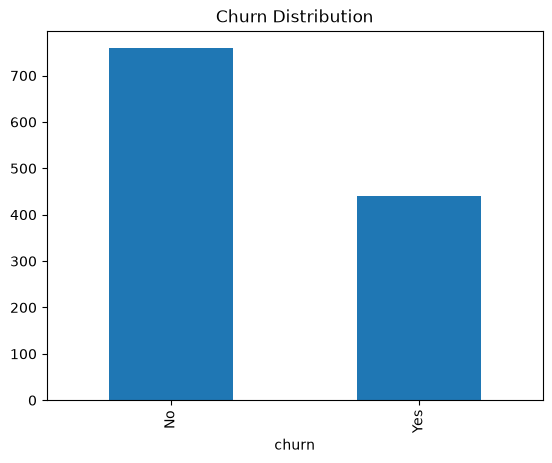

Churn rate: 36.75 %


In [5]:
df["churn"].value_counts().plot(kind="bar", title="Churn Distribution"); plt.show()
print("Churn rate:", round((df.churn=="Yes").mean()*100,2), "%")


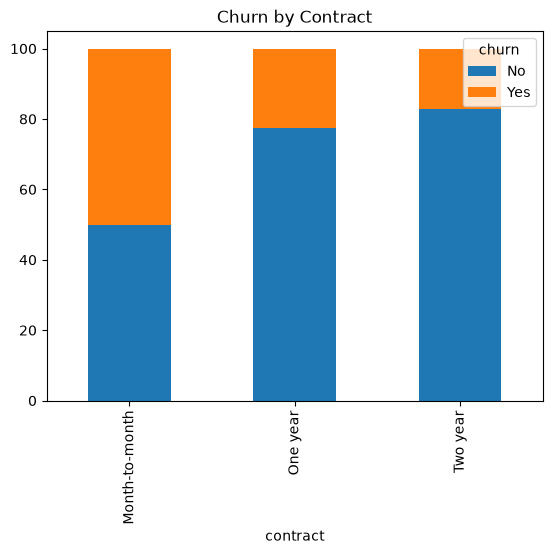

In [6]:
pd.crosstab(df.contract,df.churn,normalize="index").mul(100).plot(kind="bar",stacked=True); plt.title("Churn by Contract"); plt.show()


In [7]:
X=df.drop(columns=["customer_id","churn"]); y=(df.churn=="Yes").astype(int)
cat=X.select_dtypes(include="object").columns.tolist(); num=X.select_dtypes(exclude="object").columns.tolist()
pre=ColumnTransformer([("num",Pipeline([("imp",SimpleImputer(strategy="median")),("scale",StandardScaler())]),num),("cat",Pipeline([("imp",SimpleImputer(strategy="most_frequent")),("oh",OneHotEncoder(handle_unknown="ignore"))]),cat)])
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42,stratify=y)


C:\Users\MS\AppData\Local\Temp\ipykernel_14284\1711350733.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat=X.select_dtypes(include="object").columns.tolist(); num=X.select_dtypes(exclude="object").columns.tolist()


In [8]:
lr=Pipeline([("pre",pre),("model",LogisticRegression(max_iter=1000,class_weight="balanced"))])
lr.fit(X_train,y_train); p=lr.predict(X_test); prob=lr.predict_proba(X_test)[:,1]
print(classification_report(y_test,p)); print("ROC-AUC:",roc_auc_score(y_test,prob))


              precision    recall  f1-score   support

           0       0.76      0.62      0.68       152
           1       0.50      0.67      0.58        88

    accuracy                           0.64       240
   macro avg       0.63      0.64      0.63       240
weighted avg       0.67      0.64      0.64       240

ROC-AUC: 0.7210675837320575


In [9]:
rf=Pipeline([("pre",pre),("model",RandomForestClassifier(n_estimators=250,max_depth=8,class_weight="balanced",random_state=42))])
rf.fit(X_train,y_train); p2=rf.predict(X_test); prob2=rf.predict_proba(X_test)[:,1]
print(classification_report(y_test,p2)); print("ROC-AUC:",roc_auc_score(y_test,prob2))


              precision    recall  f1-score   support

           0       0.74      0.63      0.68       152
           1       0.50      0.62      0.55        88

    accuracy                           0.63       240
   macro avg       0.62      0.63      0.62       240
weighted avg       0.65      0.63      0.64       240

ROC-AUC: 0.6841357655502391


In [10]:
results=pd.DataFrame({"Model":["Logistic Regression","Random Forest"],"Accuracy":[accuracy_score(y_test,p),accuracy_score(y_test,p2)],"Recall":[recall_score(y_test,p),recall_score(y_test,p2)],"ROC-AUC":[roc_auc_score(y_test,prob),roc_auc_score(y_test,prob2)]})
display(results.round(4))


,Model,Accuracy,Recall,ROC-AUC
0,Logistic Regression,0.6375,0.6705,0.7211
1,Random Forest,0.6292,0.6250,0.6841


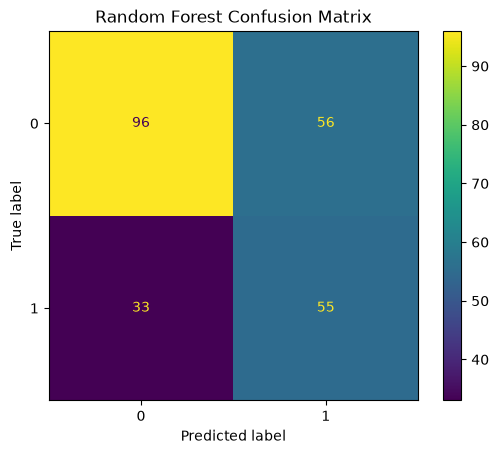

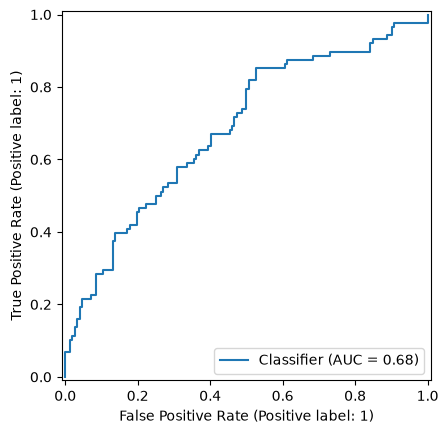

In [11]:
ConfusionMatrixDisplay.from_predictions(y_test,p2); plt.title("Random Forest Confusion Matrix"); plt.show()
RocCurveDisplay.from_predictions(y_test,prob2); plt.show()


In [12]:
# New customer details

new_customer = pd.DataFrame([{
    "gender": "Male",
    "senior_citizen": 0,
    "partner": "No",
    "dependents": "No",
    "tenure_months": 3,
    "phone_service": "Yes",
    "internet_service": "Fiber optic",
    "contract": "Month-to-month",
    "payment_method": "Electronic check",
    "paperless_billing": "Yes",
    "monthly_charges": 95.0,
    "total_charges": 285.0
}])

# Prediction
prediction = rf.predict(new_customer)[0]

# Probability
probability = rf.predict_proba(new_customer)[0, 1]

print("Predicted Churn:", "Yes" if prediction == 1 else "No")
print("Churn Probability:", round(probability * 100, 2), "%")

Predicted Churn: Yes
Churn Probability: 85.65 %


## Conclusion

Use the model to identify customers at risk of churn. Focus on short-tenure customers, month-to-month contracts and high monthly charges. This dataset is synthetic for educational use.